# 24-788 Mini-Project: Breast Cancer Classification — CBIS-DDSM

### Team Members:
1. Aadya Goel (aadyag)
2. Amisha Dhawan (adhawan)

**Models:** ANN (Baseline) | ResNet50 | EfficientNetB0  
**Framework:** TensorFlow / Keras  

**Dataset:** [CBIS-DDSM on Kaggle](https://www.kaggle.com/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset)

## 1. Imports & Configuration

In [21]:
import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import ResNet50, EfficientNetB0
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve)

SEED         = 42
IMG_SIZE     = 224
BATCH_SIZE   = 32
EPOCHS       = 30
LR           = 1e-4
# CKPT_DIR     = "/content/checkpoints"
# DATA_ROOT    = "/content/cbis-ddsm"
# os.makedirs(CKPT_DIR, exist_ok=True)

tf.random.set_seed(SEED)
np.random.seed(SEED)
print("TF:", tf.__version__, "| GPU:", tf.config.list_physical_devices('GPU'))

TF: 2.19.0 | GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Build DataFrame from CSVs + Image Paths

The Kaggle dataset has:
- `csv/` — metadata CSVs with `pathology` and `image file path` columns  
- `jpeg/` — pre-converted JPEG images

We merge mass + calcification CSVs, map image paths to actual files, and binarize labels.


In [22]:
DATA_ROOT = "/kaggle/input/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset"
csv_dir   = os.path.join(DATA_ROOT, "csv")
img_dir   = os.path.join(DATA_ROOT, "jpeg")

CKPT_DIR  = "/kaggle/working/checkpoints"
os.makedirs(CKPT_DIR, exist_ok=True)

In [23]:
import pandas as pd

csv_dir = "/kaggle/input/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset/csv"
img_dir = "/kaggle/input/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset/jpeg"

def load_split(split="train"):
    calc = pd.read_csv(f"{csv_dir}/calc_case_description_{split}_set.csv")
    mass = pd.read_csv(f"{csv_dir}/mass_case_description_{split}_set.csv")
    return pd.concat([calc, mass], ignore_index=True)

df_train_raw = load_split("train")
df_test_raw  = load_split("test")

print("Train CSV shape:", df_train_raw.shape)
print("Test  CSV shape:", df_test_raw.shape)
print("\nPathology value counts (train):")
print(df_train_raw["pathology"].value_counts())

Train CSV shape: (2864, 17)
Test  CSV shape: (704, 17)

Pathology value counts (train):
pathology
MALIGNANT                  1181
BENIGN                     1105
BENIGN_WITHOUT_CALLBACK     578
Name: count, dtype: int64


In [24]:
# Load dicom_info and filter to full mammograms only
dicom_info = pd.read_csv(f"{csv_dir}/dicom_info.csv")
full_mammo = dicom_info[dicom_info["SeriesDescription"] == "full mammogram images"].copy()

# image_path looks like: CBIS-DDSM/jpeg/1.3.6.../000000.jpg
# Convert to actual Kaggle path: /kaggle/input/.../jpeg/1.3.6.../000000.jpg
full_mammo["abs_path"] = full_mammo["image_path"].apply(
    lambda x: os.path.join(
        "/kaggle/input/cbis-ddsm-breast-cancer-image-dataset",
        str(x).replace("CBIS-DDSM/", "")
    )
)

# Build lookup: PatientID (strip trailing _1, _2 suffixes) -> abs_path
# CSV folders: Calc-Training_P_00005_RIGHT_CC
# PatientID:   Calc-Training_P_00005_RIGHT_CC  or  Calc-Training_P_00005_RIGHT_CC_1
# We strip the trailing _N to normalise
def strip_suffix(pid):
    parts = str(pid).split("_")
    if parts[-1].isdigit():
        return "_".join(parts[:-1])
    return pid

full_mammo["key"] = full_mammo["PatientID"].apply(strip_suffix)
img_lookup = dict(zip(full_mammo["key"], full_mammo["abs_path"]))

print(f"Lookup entries: {len(img_lookup)}")
print("Sample:", list(img_lookup.items())[:3])

Lookup entries: 2857
Sample: [('Mass-Training_P_01754_RIGHT_CC', '/kaggle/input/cbis-ddsm-breast-cancer-image-dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.248386742010678582309005372213277814849/1-249.jpg'), ('Calc-Training_P_00232_RIGHT_CC', '/kaggle/input/cbis-ddsm-breast-cancer-image-dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.267213171011171858918434139331210917771/1-032.jpg'), ('Mass-Training_P_01206_RIGHT_MLO', '/kaggle/input/cbis-ddsm-breast-cancer-image-dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.210396893911234385024533119100226540488/1-128.jpg')]


In [25]:
# Rebuild lookup by walking the actual jpeg directory on disk
# This guarantees we only reference files that actually exist

def build_image_lookup(img_dir, full_mammo):
    """
    For each key in full_mammo, find the actual jpg file on disk
    by walking the UID folder.
    """
    lookup = {}
    for _, row in full_mammo.iterrows():
        key = row["key"]
        if key in lookup:
            continue
        # Get the UID folder from the image_path
        # image_path: CBIS-DDSM/jpeg/<UID>/filename.jpg
        parts = str(row["image_path"]).replace("CBIS-DDSM/jpeg/", "").split("/")
        uid_folder = parts[0]
        folder_path = os.path.join(img_dir, uid_folder)
        
        if not os.path.isdir(folder_path):
            continue
        
        # Find any jpg in this folder
        jpgs = []
        for f in os.listdir(folder_path):
            if f.lower().endswith(".jpg") or f.lower().endswith(".jpeg"):
                jpgs.append(os.path.join(folder_path, f))
        
        if jpgs:
            lookup[key] = sorted(jpgs)[0]  # take first jpg found
    
    return lookup

img_lookup = build_image_lookup(img_dir, full_mammo)
print(f"Lookup entries: {len(img_lookup)}")

# Verify a few paths actually exist
sample_paths = list(img_lookup.values())[:5]
for p in sample_paths:
    print(os.path.exists(p), p)

Lookup entries: 2857
True /kaggle/input/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.248386742010678582309005372213277814849/1-249.jpg
True /kaggle/input/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.267213171011171858918434139331210917771/1-032.jpg
True /kaggle/input/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.210396893911234385024533119100226540488/1-128.jpg
True /kaggle/input/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.74956658311383957201426978750903861062/1-248.jpg
True /kaggle/input/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.98765885412946410823689524902893984551/1-007.jpg


In [26]:
def prepare_df(df_raw, img_lookup):
    df = df_raw.copy()
    df["pathology"] = df["pathology"].str.strip()
    df["pathology"] = df["pathology"].replace("BENIGN_WITHOUT_CALLBACK", "BENIGN")
    df = df[df["pathology"].isin(["BENIGN", "MALIGNANT"])].copy()

    # Strip trailing _N suffix to match lookup keys
    def strip_suffix(s):
        parts = str(s).split("/")[0].split("_")
        if parts[-1].isdigit():
            return "_".join(parts[:-1])
        return str(s).split("/")[0]

    df["folder"] = df["image file path"].apply(strip_suffix)
    df["img_path"] = df["folder"].map(img_lookup)

    missing = df["img_path"].isna().sum()
    if missing > 0:
        print(f"Warning: {missing} rows had no matching image — dropping them.")
    df = df.dropna(subset=["img_path"]).reset_index(drop=True)
    df["label"] = (df["pathology"] == "MALIGNANT").astype(int)
    return df[["img_path", "label", "pathology", "folder"]]

In [27]:
from sklearn.model_selection import train_test_split

df_train_full = prepare_df(df_train_raw, img_lookup)
df_test       = prepare_df(df_test_raw,  img_lookup)

df_train, df_val = train_test_split(
    df_train_full, test_size=0.1, random_state=SEED, stratify=df_train_full["label"]
)

print(f"Train: {len(df_train)} | Val: {len(df_val)} | Test: {len(df_test)}")
print("\nLabel distribution (train):")
print(df_train["pathology"].value_counts())
print("\nLabel distribution (test):")
print(df_test["pathology"].value_counts())

Train: 2577 | Val: 287 | Test: 422

Label distribution (train):
pathology
BENIGN       1514
MALIGNANT    1063
Name: count, dtype: int64

Label distribution (test):
pathology
BENIGN       248
MALIGNANT    174
Name: count, dtype: int64


In [28]:
print(f"Train: {len(df_train)} | Val: {len(df_val)} | Test: {len(df_test)}")
print("\nLabel distribution (train):")
print(df_train["pathology"].value_counts())
print("\nLabel distribution (test):")
print(df_test["pathology"].value_counts())

Train: 2577 | Val: 287 | Test: 422

Label distribution (train):
pathology
BENIGN       1514
MALIGNANT    1063
Name: count, dtype: int64

Label distribution (test):
pathology
BENIGN       248
MALIGNANT    174
Name: count, dtype: int64


## 3. tf.data Pipeline

In [29]:
def load_and_preprocess(img_path, label):
    img = tf.io.read_file(img_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32) / 255.0
    return img, label

def augment(img, label):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)
    img = tf.image.random_brightness(img, max_delta=0.1)
    img = tf.image.random_contrast(img, lower=0.9, upper=1.1)
    img = tf.clip_by_value(img, 0.0, 1.0)
    return img, label

def make_dataset(df, shuffle=False, augment_data=False):
    AUTOTUNE = tf.data.AUTOTUNE
    paths  = df["img_path"].values
    labels = df["label"].values.astype("float32")
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
    if augment_data:
        ds = ds.map(augment, num_parallel_calls=AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(buffer_size=1000, seed=SEED)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

train_ds = make_dataset(df_train, shuffle=True, augment_data=True)
val_ds   = make_dataset(df_val)
test_ds  = make_dataset(df_test)
print("Datasets built.")

Datasets built.


### Visualise Sample Images

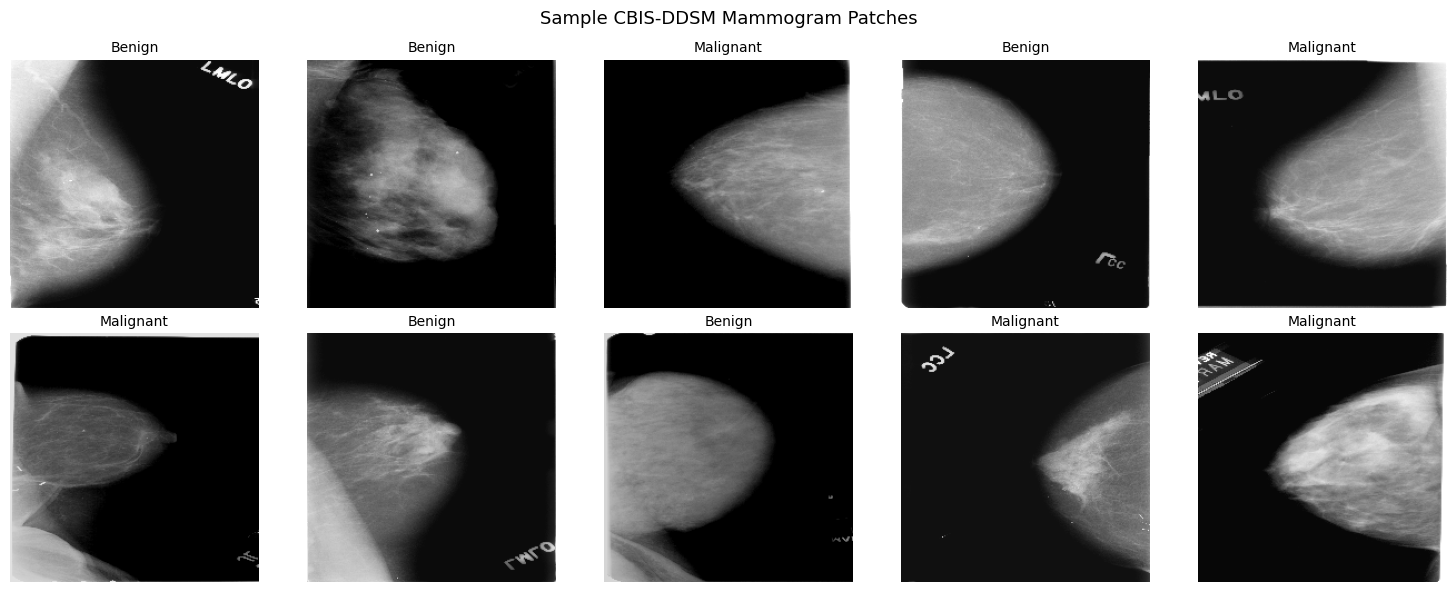

In [30]:
class_names = {0: "Benign", 1: "Malignant"}
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for images, labels in train_ds.take(1):
    for i, ax in enumerate(axes.flat):
        ax.imshow(images[i].numpy())
        ax.set_title(class_names[int(labels[i])], fontsize=10)
        ax.axis("off")
plt.suptitle("Sample CBIS-DDSM Mammogram Patches", fontsize=13)
plt.tight_layout()
plt.savefig("sample_images.png", dpi=150, bbox_inches="tight")
plt.show()

### Class Distribution

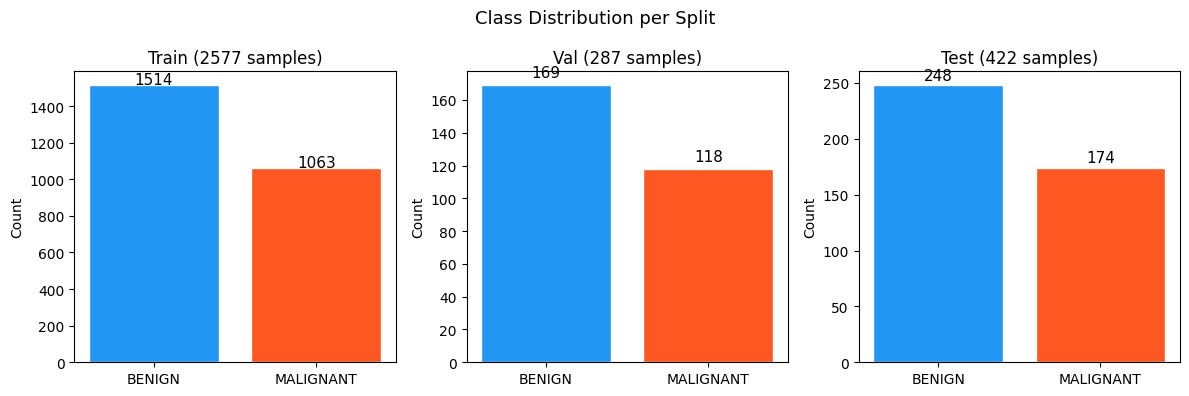

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, (split_name, df_split) in zip(axes, [("Train", df_train), ("Val", df_val), ("Test", df_test)]):
    counts = df_split["pathology"].value_counts()
    ax.bar(counts.index, counts.values, color=["#2196F3", "#FF5722"], edgecolor="white")
    ax.set_title(f"{split_name} ({len(df_split)} samples)")
    ax.set_ylabel("Count")
    for i, v in enumerate(counts.values):
        ax.text(i, v + 5, str(v), ha="center", fontsize=11)
plt.suptitle("Class Distribution per Split", fontsize=13)
plt.tight_layout()
plt.savefig("class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Model Definitions

### Why these three?
| Model | Inductive Bias | Key Idea |
|---|---|---|
| **ANN** | None — treats each pixel independently | Baseline: no spatial structure assumed |
| **ResNet50** | Translation invariance, local receptive fields | Skip connections prevent vanishing gradients |
| **EfficientNetB0** | Same as CNN + compound scaling | Jointly scales depth/width/resolution for efficiency |


### 4a. ANN Baseline

In [13]:
# def build_ann(input_shape=(IMG_SIZE, IMG_SIZE, 3)):
#     inputs = keras.Input(shape=input_shape, name="input")
#     x = layers.Flatten()(inputs)
#     x = layers.Dense(1024, activation="relu")(x)
#     x = layers.BatchNormalization()(x)
#     x = layers.Dropout(0.4)(x)
#     x = layers.Dense(512, activation="relu")(x)
#     x = layers.BatchNormalization()(x)
#     x = layers.Dropout(0.4)(x)
#     x = layers.Dense(256, activation="relu")(x)
#     x = layers.Dropout(0.3)(x)
#     outputs = layers.Dense(1, activation="sigmoid", name="output")(x)
#     return keras.Model(inputs, outputs, name="ANN_Baseline")

# ann = build_ann()
# ann.summary()

In [33]:
def build_ann(input_shape=(IMG_SIZE, IMG_SIZE, 3)):
    inputs = keras.Input(shape=input_shape, name="input")
    x = layers.Flatten()(inputs)
    x = layers.Dense(512, activation="relu",
                     kernel_initializer="he_normal")(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(256, activation="relu",
                     kernel_initializer="he_normal")(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(128, activation="relu",
                     kernel_initializer="he_normal")(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(1, activation="sigmoid", name="output")(x)
    return keras.Model(inputs, outputs, name="ANN_Baseline")

### 4b. Variant 1 — ResNet50 (Transfer Learning)

In [34]:
def build_resnet50(input_shape=(IMG_SIZE, IMG_SIZE, 3)):
    base = ResNet50(weights="imagenet", include_top=False, input_shape=input_shape)
    base.trainable = False  # freeze base; only train head

    inputs = keras.Input(shape=input_shape, name="input")
    x = tf.keras.applications.resnet50.preprocess_input(inputs * 255.0)
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation="sigmoid", name="output")(x)
    return keras.Model(inputs, outputs, name="ResNet50_Transfer")

resnet50 = build_resnet50()
resnet50.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "ResNet50_Transfer"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 224, 224,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 224, 224,  │          0 │ input[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ multiply[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ multiply[0][0]    │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ multiply[0][0]    │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 256)       │    524,544 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256)       │      1,024 │ dense_3[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 256)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │        257 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 24,113,537 (91.99 MB)

 Trainable params: 525,313 (2.00 MB)

 Non-trainable params: 23,588,224 (89.98 MB)

### 4c. Variant 2 — EfficientNetB0 (Transfer Learning)

In [46]:
def build_efficientnetb0(input_shape=(IMG_SIZE, IMG_SIZE, 3)):
    base = EfficientNetB0(weights="imagenet", include_top=False, input_shape=input_shape)
    base.trainable = False

    inputs = keras.Input(shape=input_shape, name="input")
    # Pipeline normalises images to [0,1]; EfficientNetB0 has its own internal
    # normalisation but still expects raw pixel values in [0,255].
    # Rescale back to [0,255] before passing to the backbone.
    x = layers.Rescaling(255.0)(inputs)
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation="sigmoid", name="output")(x)
    return keras.Model(inputs, outputs, name="EfficientNetB0_Transfer")

efficientnet = build_efficientnetb0()
efficientnet.summary()

Model: "EfficientNetB0_Transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_10 (Rescaling)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,378,788 (16.70 MB)

 Trainable params: 328,705 (1.25 MB)

 Non-trainable params: 4,050,083 (15.45 MB)

## 5. Training

In [36]:
def get_callbacks(name):
    return [
        EarlyStopping(monitor="val_loss", patience=5,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                          patience=3, min_lr=1e-7, verbose=1),
        ModelCheckpoint(
            filepath=os.path.join(CKPT_DIR, f"{name}_best.keras"),
            monitor="val_loss", save_best_only=True, verbose=1
        ),
    ]

def compile_and_train(model, lr=LR):
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            keras.metrics.AUC(name="auc"),
            keras.metrics.Precision(name="precision"),
            keras.metrics.Recall(name="recall"),
        ]
    )
    history = model.fit(
        train_ds, validation_data=val_ds,
        epochs=EPOCHS,
        callbacks=get_callbacks(model.name),
        verbose=1,
    )
    return history

### Train ANN

In [39]:
ann = build_ann()
ann.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),  # lower than before
    loss="binary_crossentropy",
    metrics=["accuracy",
             keras.metrics.AUC(name="auc"),
             keras.metrics.Precision(name="precision"),
             keras.metrics.Recall(name="recall")]
)
history_ann = ann.fit(
    train_ds, validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=get_callbacks("ANN_Baseline"),
    verbose=1
)

ann.save(os.path.join(CKPT_DIR, "ANN_Baseline_final.keras"))

Epoch 1/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 659ms/step - accuracy: 0.5616 - auc: 0.5308 - loss: 0.7696 - precision: 0.4564 - recall: 0.3664
Epoch 1: val_loss improved from inf to 0.68688, saving model to /kaggle/working/checkpoints/ANN_Baseline_best.keras
81/81 ━━━━━━━━━━━━━━━━━━━━ 107s 850ms/step - accuracy: 0.5614 - auc: 0.5305 - loss: 0.7699 - precision: 0.4560 - recall: 0.3659 - val_accuracy: 0.5436 - val_auc: 0.6251 - val_loss: 0.6869 - val_precision: 0.4656 - val_recall: 0.7458 - learning_rate: 1.0000e-05
Epoch 2/30
78/81 ━━━━━━━━━━━━━━━━━━━━ 1s 664ms/step - accuracy: 0.5535 - auc: 0.5201 - loss: 0.7260 - precision: 0.4173 - recall: 0.3436
Epoch 2: val_loss improved from 0.68688 to 0.67922, saving model to /kaggle/working/checkpoints/ANN_Baseline_best.keras
81/81 ━━━━━━━━━━━━━━━━━━━━ 99s 806ms/step - accuracy: 0.5533 - auc: 0.5200 - loss: 0.7262 - precision: 0.4182 - recall: 0.3428 - val_accuracy: 0.5749 - val_auc: 0.5927 - val_loss: 0.6792 - val_precision: 0.4851 - val_recall: 0.55

In [40]:
# List saved checkpoints so you can verify they exist
import glob
print(glob.glob(f"{CKPT_DIR}/*.keras"))

['/kaggle/working/checkpoints/ANN_Baseline_best.keras', '/kaggle/working/checkpoints/ANN_Baseline_final.keras']


### Train ResNet50

In [47]:
history_resnet = compile_and_train(resnet50)
resnet50.save(os.path.join(CKPT_DIR, "ResNet50_Transfer_final.keras"))

Epoch 1/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 725ms/step - accuracy: 0.5201 - auc: 0.5356 - loss: 0.9592 - precision: 0.4151 - recall: 0.5209
Epoch 1: val_loss improved from inf to 0.59831, saving model to /kaggle/working/checkpoints/ResNet50_Transfer_best.keras
81/81 ━━━━━━━━━━━━━━━━━━━━ 123s 940ms/step - accuracy: 0.5206 - auc: 0.5363 - loss: 0.9581 - precision: 0.4158 - recall: 0.5215 - val_accuracy: 0.6620 - val_auc: 0.7354 - val_loss: 0.5983 - val_precision: 0.5840 - val_recall: 0.6186 - learning_rate: 1.0000e-04
Epoch 2/30
80/81 ━━━━━━━━━━━━━━━━━━━━ 0s 678ms/step - accuracy: 0.6324 - auc: 0.6813 - loss: 0.7413 - precision: 0.5292 - recall: 0.6298
Epoch 2: val_loss did not improve from 0.59831
81/81 ━━━━━━━━━━━━━━━━━━━━ 96s 781ms/step - accuracy: 0.6321 - auc: 0.6808 - loss: 0.7418 - precision: 0.5293 - recall: 0.6293 - val_accuracy: 0.6585 - val_auc: 0.7325 - val_loss: 0.6040 - val_precision: 0.5877 - val_recall: 0.5678 - learning_rate: 1.0000e-04
Epoch 3/30
80/81 ━━━━━━━━━━━━━━━━━━━━

In [48]:
# List saved checkpoints so you can verify they exist
import glob
print(glob.glob(f"{CKPT_DIR}/*.keras"))

['/kaggle/working/checkpoints/ResNet50_Transfer_best.keras', '/kaggle/working/checkpoints/ResNet50_Transfer_final.keras', '/kaggle/working/checkpoints/ANN_Baseline_best.keras', '/kaggle/working/checkpoints/ANN_Baseline_final.keras']


In [49]:
import shutil

# Copy checkpoints to kaggle/working root so they appear in Output tab
for f in glob.glob(f"{CKPT_DIR}/*.keras"):
    dest = f"/kaggle/working/{os.path.basename(f)}"
    shutil.copy(f, dest)
    print(f"Copied to: {dest}")

Copied to: /kaggle/working/ResNet50_Transfer_best.keras
Copied to: /kaggle/working/ResNet50_Transfer_final.keras
Copied to: /kaggle/working/ANN_Baseline_best.keras
Copied to: /kaggle/working/ANN_Baseline_final.keras


### Train EfficientNetB0

In [50]:
history_eff = compile_and_train(efficientnet)
efficientnet.save(os.path.join(CKPT_DIR, "EfficientNetB0_Transfer_final.keras"))

Epoch 1/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 786ms/step - accuracy: 0.5218 - auc: 0.5265 - loss: 0.9221 - precision: 0.4379 - recall: 0.5286
Epoch 1: val_loss improved from inf to 0.65109, saving model to /kaggle/working/checkpoints/EfficientNetB0_Transfer_best.keras
81/81 ━━━━━━━━━━━━━━━━━━━━ 144s 1s/step - accuracy: 0.5221 - auc: 0.5269 - loss: 0.9216 - precision: 0.4381 - recall: 0.5288 - val_accuracy: 0.6376 - val_auc: 0.6370 - val_loss: 0.6511 - val_precision: 0.6346 - val_recall: 0.2797 - learning_rate: 1.0000e-04
Epoch 2/30
80/81 ━━━━━━━━━━━━━━━━━━━━ 0s 656ms/step - accuracy: 0.5853 - auc: 0.6115 - loss: 0.8028 - precision: 0.4813 - recall: 0.5583
Epoch 2: val_loss improved from 0.65109 to 0.62623, saving model to /kaggle/working/checkpoints/EfficientNetB0_Transfer_best.keras
81/81 ━━━━━━━━━━━━━━━━━━━━ 96s 768ms/step - accuracy: 0.5854 - auc: 0.6119 - loss: 0.8022 - precision: 0.4818 - recall: 0.5586 - val_accuracy: 0.6620 - val_auc: 0.6942 - val_loss: 0.6262 - val_precision: 0.6400

In [51]:
# List saved checkpoints so you can verify they exist
import glob
print(glob.glob(f"{CKPT_DIR}/*.keras"))

['/kaggle/working/checkpoints/EfficientNetB0_Transfer_best.keras', '/kaggle/working/checkpoints/EfficientNetB0_Transfer_final.keras', '/kaggle/working/checkpoints/ResNet50_Transfer_best.keras', '/kaggle/working/checkpoints/ResNet50_Transfer_final.keras', '/kaggle/working/checkpoints/ANN_Baseline_best.keras', '/kaggle/working/checkpoints/ANN_Baseline_final.keras']


In [52]:
import shutil

# Copy checkpoints to kaggle/working root so they appear in Output tab
for f in glob.glob(f"{CKPT_DIR}/*.keras"):
    dest = f"/kaggle/working/{os.path.basename(f)}"
    shutil.copy(f, dest)
    print(f"Copied to: {dest}")

Copied to: /kaggle/working/EfficientNetB0_Transfer_best.keras
Copied to: /kaggle/working/EfficientNetB0_Transfer_final.keras
Copied to: /kaggle/working/ResNet50_Transfer_best.keras
Copied to: /kaggle/working/ResNet50_Transfer_final.keras
Copied to: /kaggle/working/ANN_Baseline_best.keras
Copied to: /kaggle/working/ANN_Baseline_final.keras


### Fine-Tuning
After head-only training converges, unfreeze upper layers for end-to-end fine-tuning.  
This typically gives +2–4% AUC. 


In [53]:
def fine_tune(model, unfreeze_from, lr=1e-5, epochs=10):
    # Find the backbone sub-model dynamically
    base = next(
        (l for l in model.layers if isinstance(l, keras.Model)),
        None
    )
    if base is None:
        raise ValueError("No sub-model (backbone) found in model.layers")

    base.trainable = True
    for layer in base.layers[:unfreeze_from]:
        layer.trainable = False

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=["accuracy", keras.metrics.AUC(name="auc")]
    )
    return model.fit(
        train_ds, validation_data=val_ds, epochs=epochs,
        callbacks=get_callbacks(model.name + "_ft"), verbose=1
    )

history_resnet_ft = fine_tune(resnet50,    unfreeze_from=140)
history_eff_ft    = fine_tune(efficientnet, unfreeze_from=200)

Epoch 1/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 765ms/step - accuracy: 0.6296 - auc: 0.6831 - loss: 0.7334
Epoch 1: val_loss improved from inf to 0.64452, saving model to /kaggle/working/checkpoints/ResNet50_Transfer_ft_best.keras
81/81 ━━━━━━━━━━━━━━━━━━━━ 134s 963ms/step - accuracy: 0.6298 - auc: 0.6833 - loss: 0.7332 - val_accuracy: 0.7108 - val_auc: 0.7575 - val_loss: 0.6445 - learning_rate: 1.0000e-05
Epoch 2/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 675ms/step - accuracy: 0.7343 - auc: 0.8009 - loss: 0.5672
Epoch 2: val_loss did not improve from 0.64452
81/81 ━━━━━━━━━━━━━━━━━━━━ 97s 782ms/step - accuracy: 0.7342 - auc: 0.8009 - loss: 0.5672 - val_accuracy: 0.6725 - val_auc: 0.7343 - val_loss: 0.6851 - learning_rate: 1.0000e-05
Epoch 3/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 691ms/step - accuracy: 0.7901 - auc: 0.8516 - loss: 0.4828
Epoch 3: val_loss did not improve from 0.64452
81/81 ━━━━━━━━━━━━━━━━━━━━ 97s 790ms/step - accuracy: 0.7899 - auc: 0.8516 - loss: 0.4828 - val_accuracy: 0.6620 - val_auc: 0

2026-04-29 01:05:37.547869: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-29 01:05:37.754552: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-29 01:05:38.027300: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-29 01:05:38.234442: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


80/81 ━━━━━━━━━━━━━━━━━━━━ 0s 640ms/step - accuracy: 0.6168 - auc: 0.6453 - loss: 0.8038

2026-04-29 01:06:43.018317: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-29 01:06:43.227607: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-29 01:06:43.502604: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-29 01:06:43.711875: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 815ms/step - accuracy: 0.6168 - auc: 0.6453 - loss: 0.8037
Epoch 1: val_loss improved from inf to 0.57056, saving model to /kaggle/working/checkpoints/EfficientNetB0_Transfer_ft_best.keras
81/81 ━━━━━━━━━━━━━━━━━━━━ 147s 1s/step - accuracy: 0.6168 - auc: 0.6454 - loss: 0.8035 - val_accuracy: 0.7143 - val_auc: 0.7756 - val_loss: 0.5706 - learning_rate: 1.0000e-05
Epoch 2/10
80/81 ━━━━━━━━━━━━━━━━━━━━ 0s 667ms/step - accuracy: 0.6352 - auc: 0.6759 - loss: 0.7382
Epoch 2: val_loss did not improve from 0.57056
81/81 ━━━━━━━━━━━━━━━━━━━━ 95s 769ms/step - accuracy: 0.6350 - auc: 0.6758 - loss: 0.7384 - val_accuracy: 0.6899 - val_auc: 0.7614 - val_loss: 0.5970 - learning_rate: 1.0000e-05
Epoch 3/10
80/81 ━━━━━━━━━━━━━━━━━━━━ 0s 678ms/step - accuracy: 0.6405 - auc: 0.6892 - loss: 0.7260
Epoch 3: val_loss did not improve from 0.57056
81/81 ━━━━━━━━━━━━━━━━━━━━ 96s 772ms/step - accuracy: 0.6404 - auc: 0.6891 - loss: 0.7261 - val_accuracy: 0.6760 - val_auc: 0.7548 - 

In [54]:
# List saved checkpoints so you can verify they exist
import glob
print(glob.glob(f"{CKPT_DIR}/*.keras"))

['/kaggle/working/checkpoints/EfficientNetB0_Transfer_best.keras', '/kaggle/working/checkpoints/EfficientNetB0_Transfer_ft_best.keras', '/kaggle/working/checkpoints/EfficientNetB0_Transfer_final.keras', '/kaggle/working/checkpoints/ResNet50_Transfer_best.keras', '/kaggle/working/checkpoints/ResNet50_Transfer_final.keras', '/kaggle/working/checkpoints/ANN_Baseline_best.keras', '/kaggle/working/checkpoints/ANN_Baseline_final.keras', '/kaggle/working/checkpoints/ResNet50_Transfer_ft_best.keras']


In [55]:
import shutil

# Copy checkpoints to kaggle/working root so they appear in Output tab
for f in glob.glob(f"{CKPT_DIR}/*.keras"):
    dest = f"/kaggle/working/{os.path.basename(f)}"
    shutil.copy(f, dest)
    print(f"Copied to: {dest}")

Copied to: /kaggle/working/EfficientNetB0_Transfer_best.keras
Copied to: /kaggle/working/EfficientNetB0_Transfer_ft_best.keras
Copied to: /kaggle/working/EfficientNetB0_Transfer_final.keras
Copied to: /kaggle/working/ResNet50_Transfer_best.keras
Copied to: /kaggle/working/ResNet50_Transfer_final.keras
Copied to: /kaggle/working/ANN_Baseline_best.keras
Copied to: /kaggle/working/ANN_Baseline_final.keras
Copied to: /kaggle/working/ResNet50_Transfer_ft_best.keras


## 6. Evaluation

In [56]:
def evaluate_model(model, test_ds, display_name):
    y_true, y_pred_prob = [], []
    for images, labels in test_ds:
        probs = model.predict(images, verbose=0).flatten()
        y_pred_prob.extend(probs.tolist())
        y_true.extend(labels.numpy().tolist())

    y_true      = np.array(y_true)
    y_pred_prob = np.array(y_pred_prob)
    y_pred      = (y_pred_prob >= 0.5).astype(int)

    report = classification_report(
        y_true, y_pred, target_names=["Benign", "Malignant"], output_dict=True
    )
    auc = roc_auc_score(y_true, y_pred_prob)

    print(f"\n{'='*55}")
    print(f"  {display_name}")
    print(f"{'='*55}")
    print(classification_report(y_true, y_pred, target_names=["Benign", "Malignant"]))
    print(f"  AUC-ROC: {auc:.4f}")

    return {
        "model":       display_name,
        "accuracy":    report["accuracy"],
        "auc":         auc,
        "precision":   report["Malignant"]["precision"],
        "recall":      report["Malignant"]["recall"],
        "f1":          report["Malignant"]["f1-score"],
        "y_true":      y_true,
        "y_pred_prob": y_pred_prob,
    }

metrics_ann    = evaluate_model(ann,          test_ds, "ANN Baseline")
metrics_resnet = evaluate_model(resnet50,     test_ds, "ResNet50")
metrics_eff    = evaluate_model(efficientnet, test_ds, "EfficientNetB0")
all_metrics    = [metrics_ann, metrics_resnet, metrics_eff]


  ANN Baseline
              precision    recall  f1-score   support

      Benign       0.65      0.62      0.63       248
   Malignant       0.49      0.52      0.50       174

    accuracy                           0.58       422
   macro avg       0.57      0.57      0.57       422
weighted avg       0.58      0.58      0.58       422

  AUC-ROC: 0.6343

  ResNet50
              precision    recall  f1-score   support

      Benign       0.68      0.76      0.72       248
   Malignant       0.58      0.48      0.53       174

    accuracy                           0.64       422
   macro avg       0.63      0.62      0.62       422
weighted avg       0.64      0.64      0.64       422

  AUC-ROC: 0.7014

  EfficientNetB0
              precision    recall  f1-score   support

      Benign       0.67      0.73      0.70       248
   Malignant       0.56      0.49      0.53       174

    accuracy                           0.63       422
   macro avg       0.62      0.61      0.61   

## 7. Figures

In [57]:
histories    = [history_ann, history_resnet, history_eff]
model_names  = ["ANN Baseline", "ResNet50", "EfficientNetB0"]
colors       = ["#2196F3", "#FF5722", "#4CAF50"]

### Training Curves

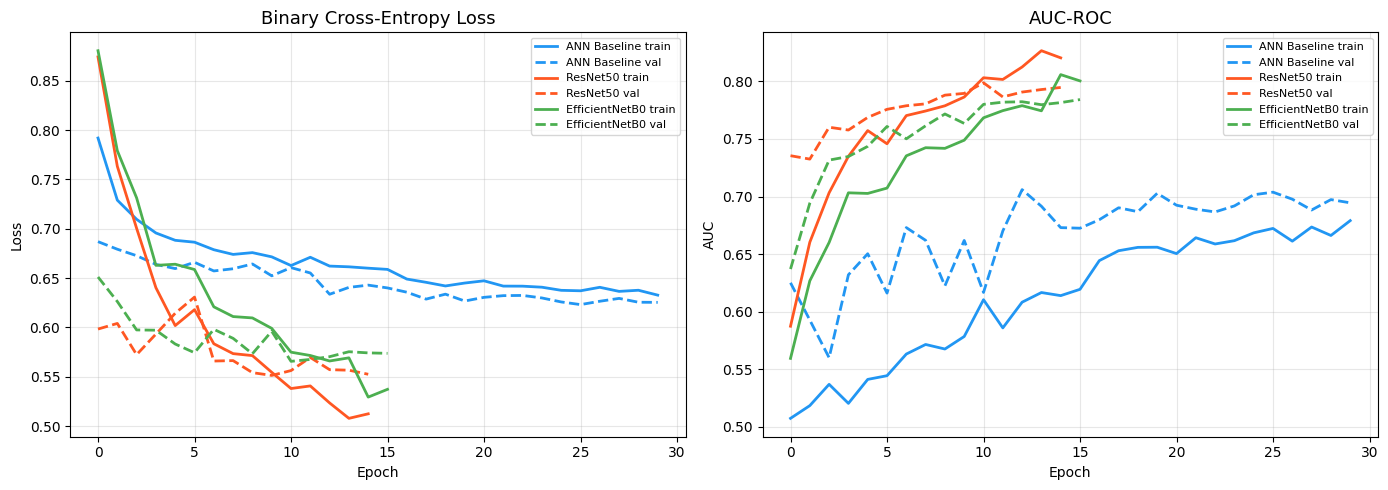

Saved: training_curves.png


In [58]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for hist, name, color in zip(histories, model_names, colors):
    axes[0].plot(hist.history["loss"],     color=color, lw=2, label=f"{name} train")
    axes[0].plot(hist.history["val_loss"], color=color, lw=2, ls="--", label=f"{name} val")
    axes[1].plot(hist.history["auc"],      color=color, lw=2, label=f"{name} train")
    axes[1].plot(hist.history["val_auc"],  color=color, lw=2, ls="--", label=f"{name} val")

for ax, title, ylabel in zip(axes, ["Binary Cross-Entropy Loss", "AUC-ROC"], ["Loss", "AUC"]):
    ax.set_title(title, fontsize=13); ax.set_xlabel("Epoch"); ax.set_ylabel(ylabel)
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: training_curves.png")

### Confusion Matrices

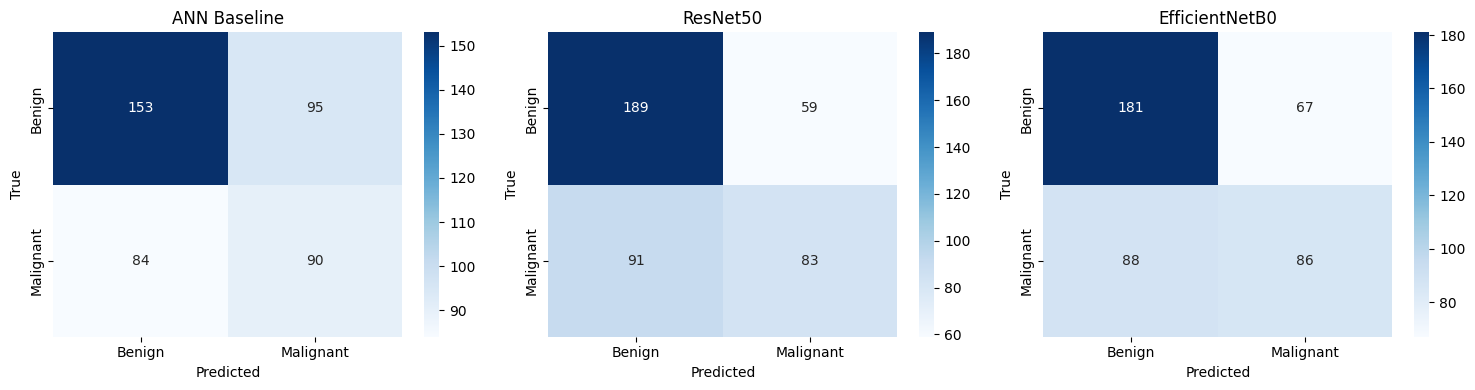

Saved: confusion_matrices.png


In [59]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, m in zip(axes, all_metrics):
    y_pred = (m["y_pred_prob"] >= 0.5).astype(int)
    cm = confusion_matrix(m["y_true"], y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Benign", "Malignant"],
                yticklabels=["Benign", "Malignant"])
    ax.set_title(m["model"]); ax.set_xlabel("Predicted"); ax.set_ylabel("True")
plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: confusion_matrices.png")

### ROC Curves

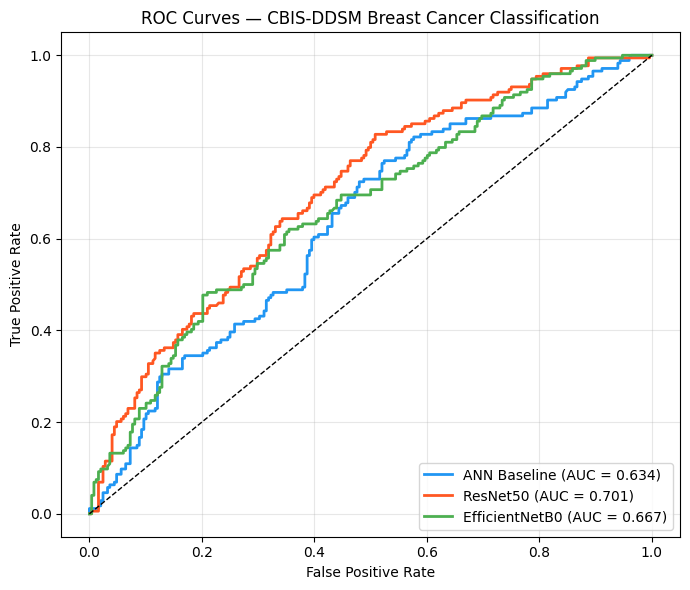

Saved: roc_curves.png


In [60]:
plt.figure(figsize=(7, 6))
for m, color in zip(all_metrics, colors):
    fpr, tpr, _ = roc_curve(m["y_true"], m["y_pred_prob"])
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f"{m['model']} (AUC = {m['auc']:.3f})")
plt.plot([0,1],[0,1],"k--", lw=1)
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curves — CBIS-DDSM Breast Cancer Classification")
plt.legend(loc="lower right"); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: roc_curves.png")

### Metric Comparison Bar Chart

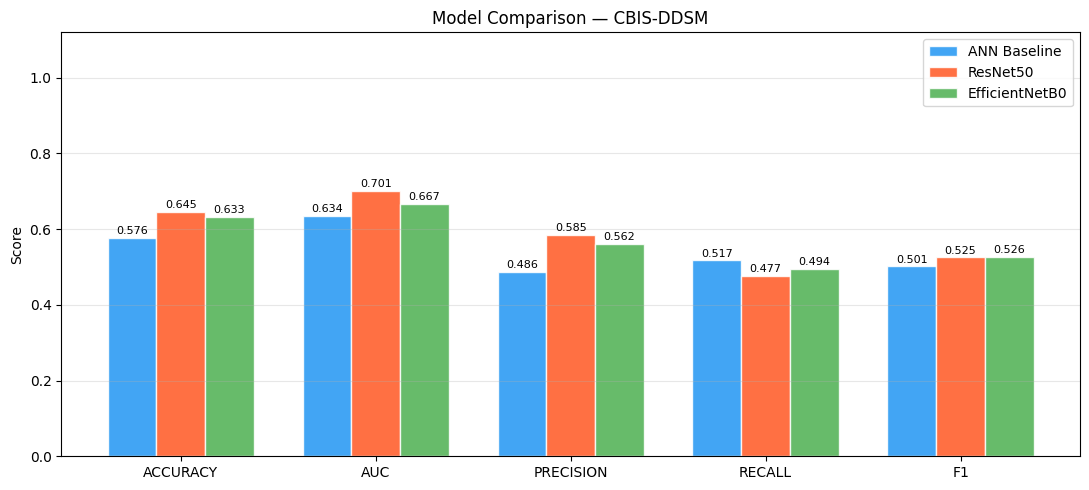

Saved: model_comparison.png


In [61]:
metric_keys = ["accuracy", "auc", "precision", "recall", "f1"]
x     = np.arange(len(metric_keys))
width = 0.25

fig, ax = plt.subplots(figsize=(11, 5))
for i, (m, color) in enumerate(zip(all_metrics, colors)):
    vals = [m[k] for k in metric_keys]
    bars = ax.bar(x + i*width, vals, width, label=m["model"],
                  color=color, alpha=0.85, edgecolor="white")
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f"{val:.3f}", ha="center", va="bottom", fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels([k.upper() for k in metric_keys])
ax.set_ylim(0, 1.12); ax.set_ylabel("Score")
ax.set_title("Model Comparison — CBIS-DDSM")
ax.legend(); ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: model_comparison.png")

# 7. Additional Analysis

/tmp/ipykernel_57/1768164712.py:55: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[2].set_yscale("log"); axes[2].legend(fontsize=9); axes[2].grid(alpha=0.3)


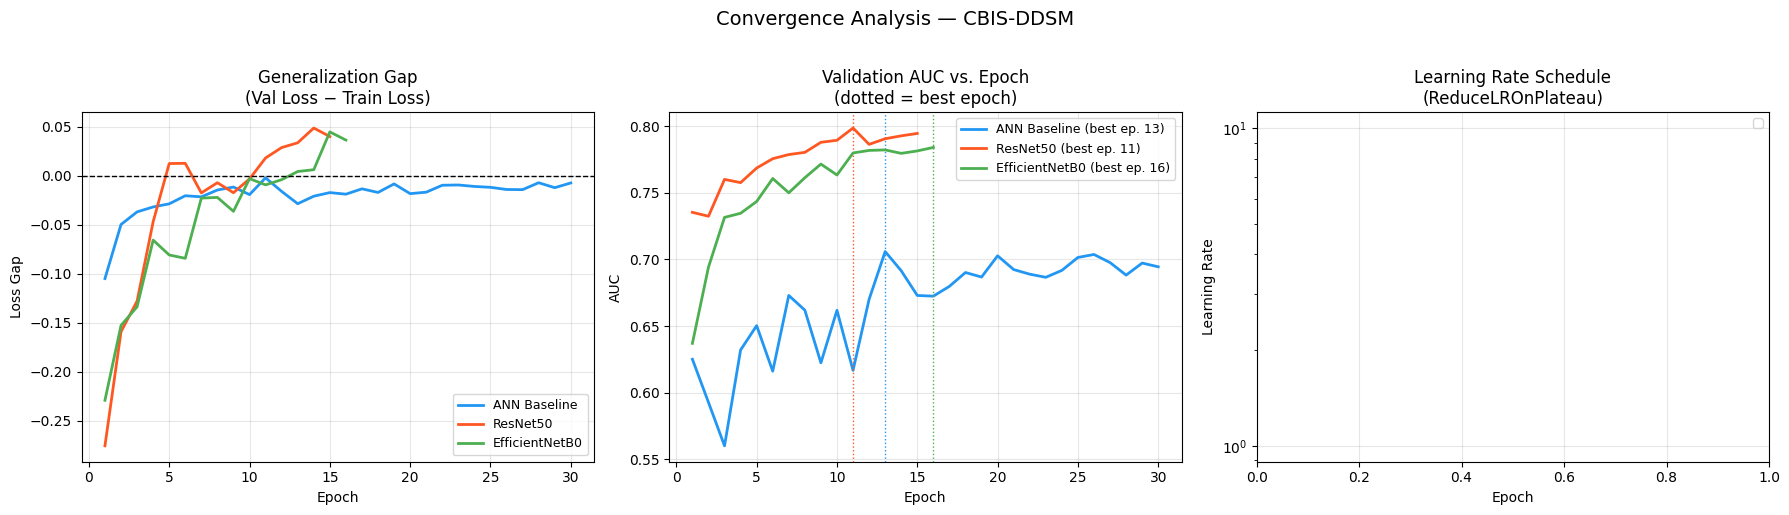

Saved: convergence_analysis.png

Model                  Best Val AUC  Best Epoch  Total Epochs   Final LR
------------------------------------------------------------------------
ANN Baseline                 0.7060          13            30        nan
ResNet50                     0.7987          11            15        nan
EfficientNetB0               0.7842          16            16        nan


In [64]:
import matplotlib.pyplot as plt
import numpy as np

# ── Convergence Analysis ───────────────────────────────────────────────────
# Assumes history_ann, history_resnet, history_eff are available
# If reloading from a new session, you'll need to retrain or save histories

histories     = [history_ann, history_resnet, history_eff]
model_names   = ["ANN Baseline", "ResNet50", "EfficientNetB0"]
colors        = ["#2196F3", "#FF5722", "#4CAF50"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for hist, name, color in zip(histories, model_names, colors):
    epochs      = range(1, len(hist.history["loss"]) + 1)
    train_loss  = hist.history["loss"]
    val_loss    = hist.history["val_loss"]
    train_auc   = hist.history["auc"]
    val_auc     = hist.history["val_auc"]
    lr          = hist.history.get("lr", [None] * len(epochs))

    # Plot 1: Loss gap (overfitting indicator)
    gap = np.array(val_loss) - np.array(train_loss)
    axes[0].plot(epochs, gap, label=name, color=color, lw=2)

# Plot 1 formatting
axes[0].axhline(0, color="black", lw=1, ls="--")
axes[0].set_title("Generalization Gap\n(Val Loss − Train Loss)", fontsize=12)
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss Gap")
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

# Plot 2: Val AUC per epoch (convergence speed)
for hist, name, color in zip(histories, model_names, colors):
    epochs    = range(1, len(hist.history["val_auc"]) + 1)
    val_auc   = hist.history["val_auc"]
    best_ep   = int(np.argmax(val_auc)) + 1
    best_auc  = max(val_auc)
    axes[1].plot(epochs, val_auc, label=f"{name} (best ep. {best_ep})",
                 color=color, lw=2)
    axes[1].axvline(best_ep, color=color, lw=1, ls=":")

axes[1].set_title("Validation AUC vs. Epoch\n(dotted = best epoch)", fontsize=12)
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("AUC")
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)

# Plot 3: Learning rate schedule (ReduceLROnPlateau effect)
for hist, name, color in zip(histories, model_names, colors):
    lr = hist.history.get("lr", None)
    if lr is not None:
        epochs = range(1, len(lr) + 1)
        axes[2].plot(epochs, lr, label=name, color=color, lw=2)

axes[2].set_title("Learning Rate Schedule\n(ReduceLROnPlateau)", fontsize=12)
axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("Learning Rate")
axes[2].set_yscale("log"); axes[2].legend(fontsize=9); axes[2].grid(alpha=0.3)

plt.suptitle("Convergence Analysis — CBIS-DDSM", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("convergence_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: convergence_analysis.png")

# ── Print convergence summary table ───────────────────────────────────────
print(f"\n{'Model':<22} {'Best Val AUC':>12} {'Best Epoch':>11} {'Total Epochs':>13} {'Final LR':>10}")
print("-" * 72)
for hist, name in zip(histories, model_names):
    val_auc    = hist.history["val_auc"]
    best_auc   = max(val_auc)
    best_ep    = int(np.argmax(val_auc)) + 1
    total_ep   = len(val_auc)
    final_lr   = hist.history.get("lr", [float("nan")])[-1]
    print(f"{name:<22} {best_auc:>12.4f} {best_ep:>11} {total_ep:>13} {final_lr:>10.2e}")

## 8. Save Results Summary

In [62]:
summary = [
    {k: float(v) if isinstance(v, (float, np.floating)) else v
     for k, v in m.items() if k not in ("y_true", "y_pred_prob")}
    for m in all_metrics
]
with open("results_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print("Saved: results_summary.json")
print(json.dumps(summary, indent=2))

Saved: results_summary.json
[
  {
    "model": "ANN Baseline",
    "accuracy": 0.5758293838862559,
    "auc": 0.6342695587690026,
    "precision": 0.4864864864864865,
    "recall": 0.5172413793103449,
    "f1": 0.5013927576601671
  },
  {
    "model": "ResNet50",
    "accuracy": 0.6445497630331753,
    "auc": 0.7013811642565814,
    "precision": 0.5845070422535211,
    "recall": 0.47701149425287354,
    "f1": 0.5253164556962026
  },
  {
    "model": "EfficientNetB0",
    "accuracy": 0.6327014218009479,
    "auc": 0.6666666666666666,
    "precision": 0.5620915032679739,
    "recall": 0.4942528735632184,
    "f1": 0.5259938837920489
  }
]


## 9. Reproduce Results (No Retraining)
Run this section independently to reload saved checkpoints and regenerate all figures.  
Make sure checkpoints are saved to Google Drive for persistence across sessions.


Loading /kaggle/working/checkpoints/ANN_Baseline_best.keras ...

  ANN Baseline
              precision    recall  f1-score   support

      Benign       0.65      0.62      0.63       248
   Malignant       0.49      0.52      0.50       174

    accuracy                           0.58       422
   macro avg       0.57      0.57      0.57       422
weighted avg       0.58      0.58      0.58       422

  AUC-ROC: 0.6343
Loading /kaggle/working/checkpoints/ResNet50_Transfer_best.keras ...

  ResNet50
              precision    recall  f1-score   support

      Benign       0.75      0.66      0.70       248
   Malignant       0.59      0.70      0.64       174

    accuracy                           0.67       422
   macro avg       0.67      0.68      0.67       422
weighted avg       0.69      0.67      0.68       422

  AUC-ROC: 0.7098
Loading /kaggle/working/checkpoints/EfficientNetB0_Transfer_best.keras ...

  EfficientNetB0
              precision    recall  f1-score   support

 

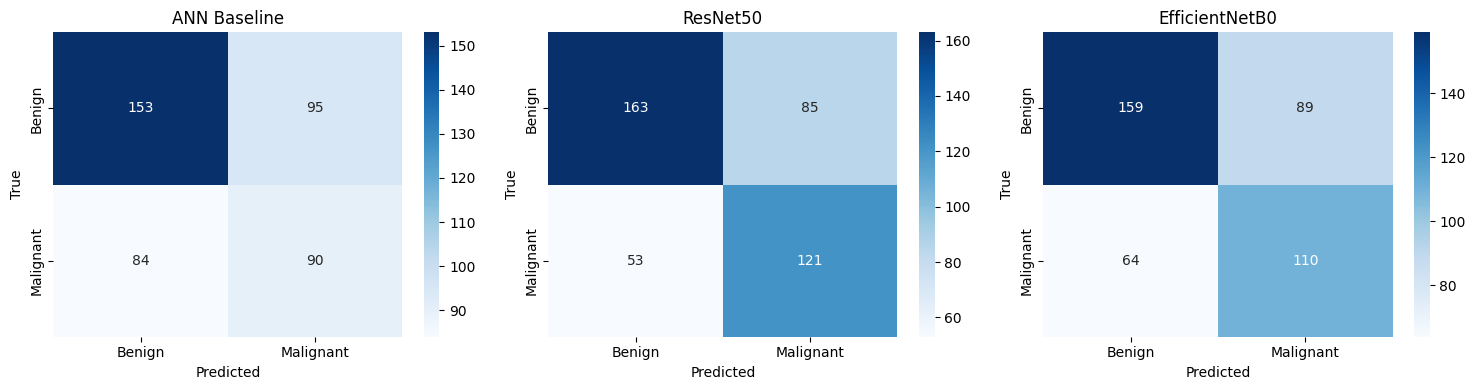

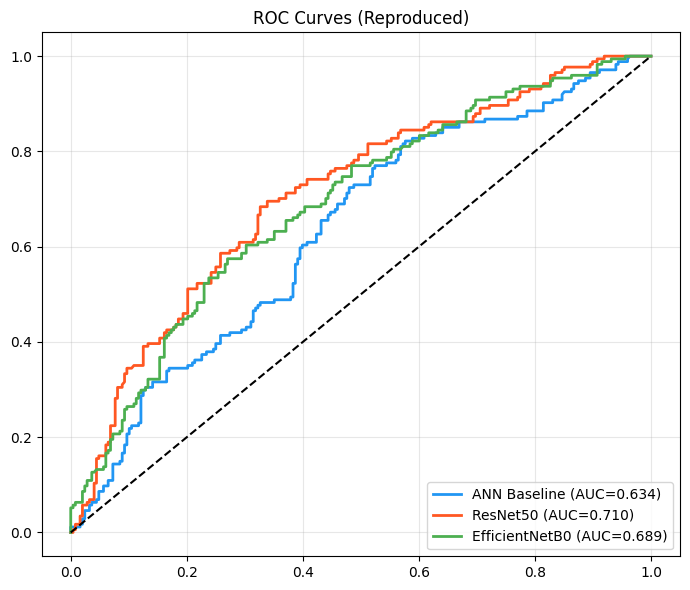


✓ Results reproduced successfully.


[{'model': 'ANN Baseline',
  'accuracy': 0.5758293838862559,
  'auc': np.float64(0.6342695587690026),
  'precision': 0.4864864864864865,
  'recall': 0.5172413793103449,
  'f1': 0.5013927576601671,
  'y_true': array([0., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 1., 0.,
         0., 1., 0., 0., 0., 1., 1., 1., 1., 1., 0., 1., 0., 1., 1., 0., 1.,
         1., 1., 0., 1., 1., 1., 0., 0., 1., 1., 1., 1., 1., 1., 0., 0., 1.,
         1., 0., 1., 1., 0., 0., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0.,
         0., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 1., 1., 1., 1., 0., 0., 0., 0., 1., 1., 0., 0., 1., 1., 1., 0.,
         0., 0., 0., 0., 0., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 1.,
         1., 0., 0., 0., 0., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.,
         1., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 0., 0., 1., 1., 1., 1.,
         1., 0., 0., 1.

In [63]:
def reproduce_results(ckpt_dir=CKPT_DIR):
    AUTOTUNE = tf.data.AUTOTUNE

    # Rebuild test dataset
    test_ds_r = make_dataset(df_test)

    model_files   = ["ANN_Baseline_best.keras",
                     "ResNet50_Transfer_best.keras",
                     "EfficientNetB0_Transfer_best.keras"]
    display_names = ["ANN Baseline", "ResNet50", "EfficientNetB0"]
    all_metrics_r = []

    for fname, display in zip(model_files, display_names):
        path = os.path.join(ckpt_dir, fname)
        print(f"Loading {path} ...")
        model = keras.models.load_model(path)
        metrics = evaluate_model(model, test_ds_r, display)
        all_metrics_r.append(metrics)

    # Regenerate key figures
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, m in zip(axes, all_metrics_r):
        y_pred = (m["y_pred_prob"] >= 0.5).astype(int)
        cm = confusion_matrix(m["y_true"], y_pred)
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                    xticklabels=["Benign","Malignant"],
                    yticklabels=["Benign","Malignant"])
        ax.set_title(m["model"]); ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    plt.tight_layout(); plt.savefig("confusion_matrices_repro.png", dpi=150); plt.show()

    plt.figure(figsize=(7,6))
    for m, color in zip(all_metrics_r, ["#2196F3","#FF5722","#4CAF50"]):
        fpr, tpr, _ = roc_curve(m["y_true"], m["y_pred_prob"])
        plt.plot(fpr, tpr, color=color, lw=2,
                 label=f"{m['model']} (AUC={m['auc']:.3f})")
    plt.plot([0,1],[0,1],"k--"); plt.legend(loc="lower right"); plt.grid(alpha=0.3)
    plt.title("ROC Curves (Reproduced)"); plt.tight_layout()
    plt.savefig("roc_curves_repro.png", dpi=150); plt.show()

    print("\n✓ Results reproduced successfully.")
    return all_metrics_r

# Uncomment to run:
reproduce_results()